In [1]:
from pathlib import Path
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [2]:
print("Current working directory:")
print(os.getcwd())

Current working directory:
c:\Users\hlarbi\Desktop\QMF Final Project (Ukraine_contrefactuel)\ukraine_counterfactual\Notebooks


In [3]:
from pathlib import Path

cwd = Path.cwd()

data_path = cwd.parent / "data" / "data_processed"

print("Data path:", data_path)
print("Exists:", data_path.exists())

Data path: c:\Users\hlarbi\Desktop\QMF Final Project (Ukraine_contrefactuel)\ukraine_counterfactual\data\data_processed
Exists: True


# Data loading 


In [4]:
df = pd.read_csv(
    data_path / "inflation_panel.csv",
    parse_dates=["date"],
    index_col="date"
)

factor = pd.read_csv(
    data_path / "euro_inflation_factor.csv",
    parse_dates=["date"],
    index_col="date"
)

print(df.shape)
print(factor.shape)

df.head()

(240, 12)
(240, 1)


,AT,BE,DE,ES,FI,FR,GR,IE,IT,NL,PT,UKR
date,,,,,,,,,,,,
2006-01-01,1.5,2.7,2.1,4.2,1.2,2.2,3.0,2.3,2.2,1.7,2.7,25.815994
2006-02-01,1.5,2.9,2.1,4.1,1.3,2.0,3.1,2.7,2.2,1.5,3.0,22.087222
2006-03-01,1.3,2.1,1.9,3.9,1.2,1.7,3.3,2.8,2.2,1.4,3.8,18.896172
2006-04-01,2.1,2.5,2.2,3.9,1.5,2.0,3.5,2.8,2.4,1.8,3.7,17.264263
2006-05-01,2.1,2.8,2.1,4.1,1.7,2.3,3.3,3.1,2.3,1.8,3.6,17.033655


# Merge Data 


In [5]:
ukr = df[["UKR"]].copy()
data = ukr.join(factor, how="inner")

print(data.shape)
data.head()

(240, 2)


,UKR,EURO_FACTOR
date,,
2006-01-01,25.815994,0.315386
2006-02-01,22.087222,0.386639
2006-03-01,18.896172,0.265889
2006-04-01,17.264263,0.656247
2006-05-01,17.033655,0.783744


# Regression

In [6]:
Y = data["UKR"]
X = sm.add_constant(data["EURO_FACTOR"])

model = sm.OLS(Y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    UKR   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     5.248
Date:                Tue, 21 Apr 2026   Prob (F-statistic):             0.0228
Time:                        12:26:10   Log-Likelihood:                -917.12
No. Observations:                 240   AIC:                             1838.
Df Residuals:                     238   BIC:                             1845.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          11.7525      0.716     16.408      

In [8]:
data["UKR_counterfactual"] = model.predict(X)

data.head()

,UKR,EURO_FACTOR,UKR_counterfactual
date,,,
2006-01-01,25.815994,0.315386,11.582962
2006-02-01,22.087222,0.386639,11.544668
2006-03-01,18.896172,0.265889,11.609564
2006-04-01,17.264263,0.656247,11.399770
2006-05-01,17.033655,0.783744,11.331248


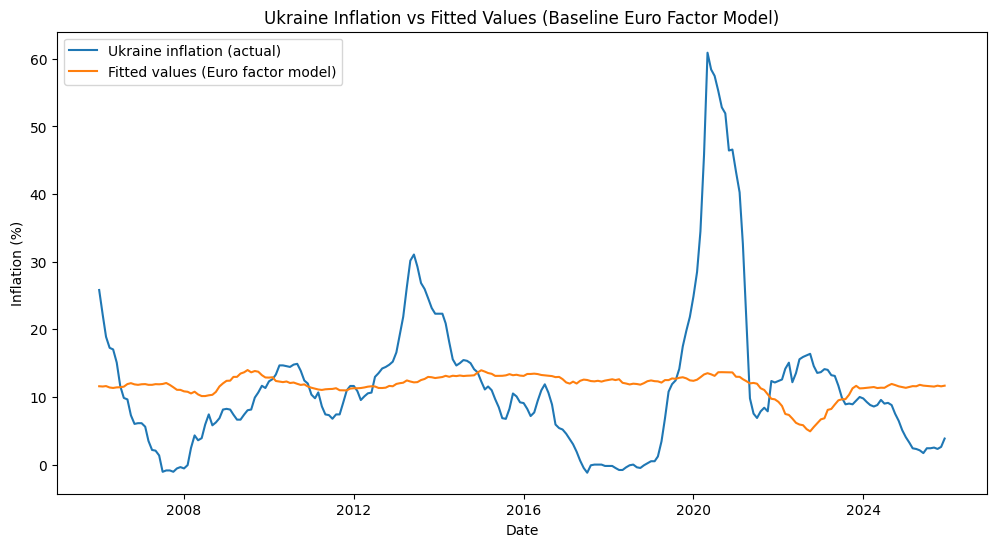

In [9]:
plt.figure(figsize=(12,6))

plt.plot(data.index, data["UKR"], label="Ukraine inflation (actual)")
plt.plot(data.index, data["UKR_counterfactual"], label="Fitted values (Euro factor model)")

plt.legend()
plt.title("Ukraine Inflation vs Fitted Values (Baseline Euro Factor Model)")
plt.xlabel("Date")
plt.ylabel("Inflation (%)")

plt.show()